## Setup

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('cville_weather_cleaned.csv')

In [3]:
def classify_weather(row):
    if row["WT06"] == 1:
        return "Ice"
    
    if row["WT04"] == 1:
        return "Sleet"
    
    if row["WT18"] == 1:
        return "Snow"
    
    if row["WT03"] == 1:
        return "Thunder"
    
    if row["WT05"] == 1:
        return "Hail"
    
    if row["WT16"] == 1 or row["PRCP"] > 0:
        if row["PRCP"] > 13:
            return "Heavy-Rain"
        elif row["WT14"] == 1:
            return "Drizzle"
        elif row["TMAX"] > 83:
            return "Hot-Rainy"
        elif row["TMIN"] < 54:
            return "Cold-Rainy"
        else:
            return "Mild-Rainy"
    
    if row["WT11"] == 1:
        return "High Winds"
    
    if row["WT01"] == 1:
        return "Fog"
    
    if row["TMAX"] > 83:
        return "Hot-Dry"
    elif row["TMIN"] < 54:
        return "Cold-Dry"
    else:
        return "Mild-Dry"

In [4]:
df["state"] = df.apply(classify_weather, axis=1)

In [5]:
df["next_day"] = df["state"].shift(-1)
df["next_2_days"] = df["state"].shift(-2)
df["next_week"] = df["state"].shift(-7)
df["next_2_weeks"] = df["state"].shift(-14)

In [6]:
df = df.dropna(subset=["next_day", "next_2_days", "next_week", "next_2_weeks"])

In [7]:
df.to_csv("cville_weather_cleaned.csv", index=False)

In [8]:
print(df.head)

<bound method NDFrame.head of           STATION        DATE                        NAME  PRCP  SNOW  SNWD  \
0     USC00441593  2000-01-01  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
1     USC00441593  2000-01-02  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
2     USC00441593  2000-01-03  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
3     USC00441593  2000-01-04  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
4     USC00441593  2000-01-05  CHARLOTTESVILLE 2 W, VA US  86.0   0.0   0.0   
...           ...         ...                         ...   ...   ...   ...   
9376  USC00441593  2025-11-01  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
9377  USC00441593  2025-11-02  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
9378  USC00441593  2025-11-03  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
9379  USC00441593  2025-11-04  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   
9380  USC00441593  2025-11-05  CHARLOTTESVILLE 2 W, VA US   0.0   0.0   0.0   

      TMAX  TMIN  WT0

In [9]:
print(df.describe())

              PRCP         SNOW         SNWD         TMAX         TMIN  \
count  9381.000000  9381.000000  9381.000000  9381.000000  9381.000000   
mean     33.005970     1.127598     4.142416    67.836478    48.182017   
std      93.658139    12.467768    26.427496    17.604150    15.939045   
min       0.000000     0.000000     0.000000    17.100000    -0.900000   
25%       0.000000     0.000000     0.000000    54.000000    35.100000   
50%       0.000000     0.000000     0.000000    70.000000    48.900000   
75%      13.000000     0.000000     0.000000    82.900000    63.000000   
max    1765.000000   419.000000   483.000000   105.100000    80.100000   

              WT01         WT03         WT04         WT05         WT06  \
count  9381.000000  9381.000000  9381.000000  9381.000000  9381.000000   
mean      0.175994     0.083040     0.009381     0.001066     0.006076   
std       0.380835     0.275958     0.096404     0.032634     0.077716   
min       0.000000     0.000000     0

## EDA

In [13]:
weather_counts_df = df.copy()
weather_counts_df["DATE"] = pd.to_datetime(weather_counts_df["DATE"])
weather_counts_df["year"] = weather_counts_df["DATE"].dt.year

state_order = list(transition_matrix.index)

transition_matrix = pd.crosstab(
    df["state"], 
    df["next_day"], 
    normalize="index"
)

# aggregate counts
aggregate_counts = (
    weather_counts_df["state"]
    .value_counts()
    .reindex(state_order, fill_value=0)
    .rename_axis("state")
    .reset_index(name="days")
)

# counts by year
counts_by_year = (
    pd.crosstab(weather_counts_df["year"], weather_counts_df["state"])
    .reindex(columns=state_order, fill_value=0)
    .sort_index()
)

# counts by season
counts_by_season = (
    pd.crosstab(weather_counts_df["season"], weather_counts_df["state"])
    .reindex(columns=state_order, fill_value=0)
)

season_order = ["Winter", "Spring", "Summer", "Fall"]
ordered_present_seasons = [s for s in season_order if s in counts_by_season.index]
remaining_seasons = [s for s in counts_by_season.index if s not in ordered_present_seasons]
counts_by_season = counts_by_season.loc[ordered_present_seasons + remaining_seasons]

print("AGGREGATE COUNTS")
display(aggregate_counts)

print("COUNTS BY YEAR")
display(counts_by_year)

print("COUNTS BY SEASON")
display(counts_by_season)

AGGREGATE COUNTS


,state,days
0,Cold-Dry,3484
1,Cold-Rainy,467
2,Fog,238
3,Heavy-Rain,1697
4,High Winds,50
5,Hot-Dry,1324
6,Hot-Rainy,149
7,Ice,57
8,Mild-Dry,852
9,Mild-Rainy,211


COUNTS BY YEAR


state,Cold-Dry,Cold-Rainy,Fog,Heavy-Rain,High Winds,Hot-Dry,Hot-Rainy,Ice,Mild-Dry,Mild-Rainy,Sleet,Thunder
year,,,,,,,,,,,,
2000,138,14,0,71,0,49,12,1,39,11,1,0
2001,155,25,1,67,0,57,15,0,33,10,0,2
2002,147,21,0,82,0,80,5,0,20,7,0,3
2003,129,25,2,114,1,32,6,0,29,9,2,16
2004,134,24,7,82,1,34,9,0,41,7,2,25
2005,136,20,1,84,1,51,7,2,39,4,2,18
2006,145,24,7,68,4,35,6,0,28,14,1,33
2007,131,16,17,60,9,53,5,0,35,6,3,30
2008,116,18,11,62,4,53,9,4,26,6,2,25


COUNTS BY SEASON


state,Cold-Dry,Cold-Rainy,Fog,Heavy-Rain,High Winds,Hot-Dry,Hot-Rainy,Ice,Mild-Dry,Mild-Rainy,Sleet,Thunder
season,,,,,,,,,,,,
Winter,1470,192,63,439,26,0,0,51,7,3,54,11
Spring,1008,167,53,481,16,184,17,2,182,40,15,197
Summer,14,1,40,362,1,917,115,0,353,96,1,492
Fall,992,107,82,415,7,223,17,4,310,72,4,78


SELF-TRANSITION (PERSISTENCE) PROBABILITIES


,state,self_transition_probability
0,Cold-Dry,0.7067
5,Hot-Dry,0.5642
8,Mild-Dry,0.3908
3,Heavy-Rain,0.3212
11,Thunder,0.3072
10,Sleet,0.2432
7,Ice,0.2105
2,Fog,0.1176
9,Mild-Rainy,0.1137
1,Cold-Rainy,0.0921


MOST COMMON NON-SELF TRANSITIONS


,from_state,to_state,count
0,Heavy-Rain,Cold-Dry,476
1,Cold-Dry,Heavy-Rain,434
2,Cold-Rainy,Cold-Dry,264
3,Hot-Dry,Thunder,230
4,Mild-Dry,Hot-Dry,210
5,Cold-Dry,Cold-Rainy,198
6,Thunder,Heavy-Rain,192
7,Heavy-Rain,Cold-Rainy,171
8,Cold-Dry,Mild-Dry,139
9,Thunder,Hot-Dry,138


RUN LENGTH SUMMARY BY STATE


,count,mean,median,max
state,,,,
Cold-Dry,1023,3.41,3.0,20
Hot-Dry,577,2.29,2.0,13
Mild-Dry,519,1.64,1.0,8
Heavy-Rain,1152,1.47,1.0,10
Thunder,539,1.44,1.0,6
Sleet,56,1.32,1.0,3
Ice,45,1.27,1.0,3
Fog,210,1.13,1.0,4
Mild-Rainy,187,1.13,1.0,3


NON-SELF TRANSITIONS WITH CONDITIONAL PROBABILITIES


,from_state,to_state,count,probability_given_from_state
0,Heavy-Rain,Cold-Dry,476,0.2805
1,Cold-Dry,Heavy-Rain,434,0.1246
2,Cold-Rainy,Cold-Dry,264,0.5653
3,Hot-Dry,Thunder,230,0.1737
4,Mild-Dry,Hot-Dry,210,0.2465
5,Cold-Dry,Cold-Rainy,198,0.0568
6,Thunder,Heavy-Rain,192,0.2468
7,Heavy-Rain,Cold-Rainy,171,0.1008
8,Cold-Dry,Mild-Dry,139,0.0399
9,Thunder,Hot-Dry,138,0.1774


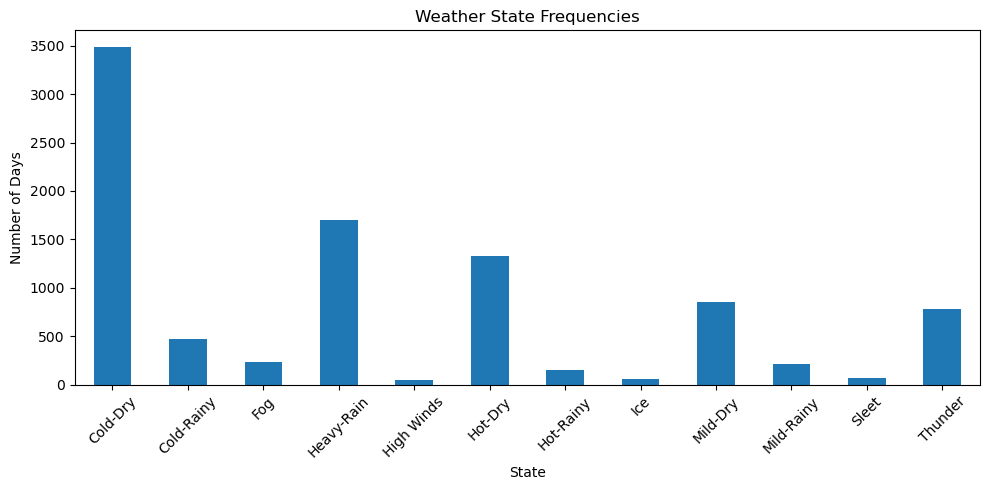

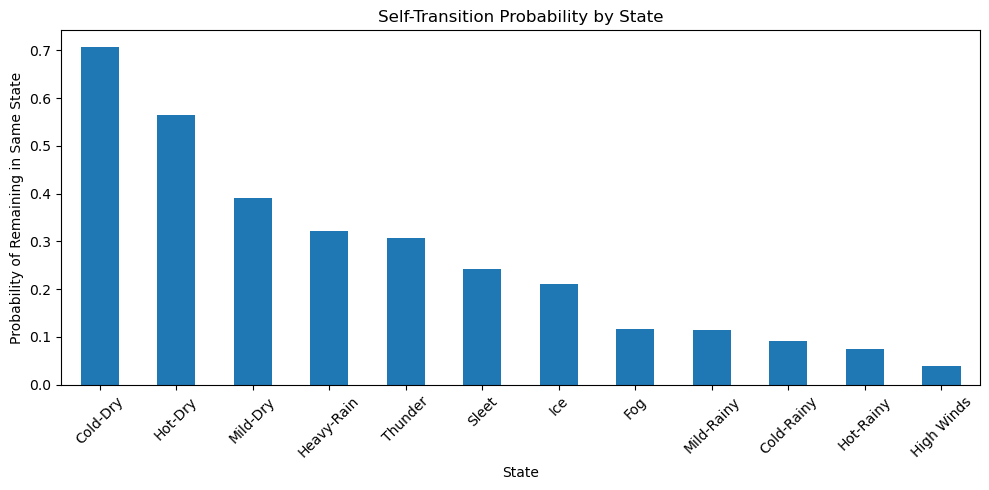

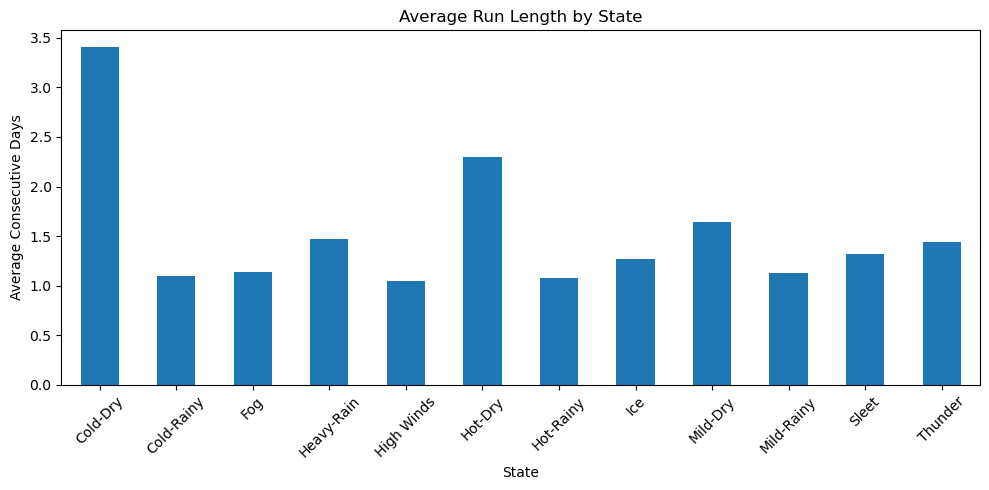

In [14]:
import numpy as np
import matplotlib.pyplot as plt

eda_df = df.copy()
eda_df["DATE"] = pd.to_datetime(eda_df["DATE"])
eda_df = eda_df.sort_values("DATE").reset_index(drop=True)
eda_df = eda_df.dropna(subset=["state"]).copy()

state_order = list(transition_matrix.index)

transition_counts = pd.crosstab(eda_df["state"], eda_df["next_day"]).reindex(
    index=state_order,
    columns=list(transition_matrix.columns),
    fill_value=0
)

# persistence probability
common_states = [s for s in transition_matrix.index if s in transition_matrix.columns]

self_transition_probs = pd.DataFrame({
    "state": common_states,
    "self_transition_probability": [transition_matrix.loc[s, s] for s in common_states]
}).sort_values("self_transition_probability", ascending=False)

print("SELF-TRANSITION (PERSISTENCE) PROBABILITIES")
display(self_transition_probs.round(4))

# most common changes in state
off_diag = transition_counts.copy()

for s in off_diag.index:
    if s in off_diag.columns:
        off_diag.loc[s, s] = 0

common_transitions = (
    off_diag.stack()
    .reset_index()
    .rename(columns={"state": "from_state", "next_day": "to_state", 0: "count"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("MOST COMMON NON-SELF TRANSITIONS")
display(common_transitions.head(15))

# how long each state persists
eda_df["state_block"] = (eda_df["state"] != eda_df["state"].shift()).cumsum()

run_lengths = (
    eda_df.groupby(["state_block", "state"])
    .size()
    .reset_index(name="run_length_days")
)

run_length_summary = (
    run_lengths.groupby("state")["run_length_days"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print("RUN LENGTH SUMMARY BY STATE")
display(run_length_summary.round(2))

# probabilities of changes in state
row_totals = transition_counts.sum(axis=1)

sudden_transition_table = common_transitions.copy()
sudden_transition_table["probability_given_from_state"] = sudden_transition_table.apply(
    lambda r: (
        r["count"] / row_totals.loc[r["from_state"]]
        if row_totals.loc[r["from_state"]] > 0 else np.nan
    ),
    axis=1
)

print("NON-SELF TRANSITIONS WITH CONDITIONAL PROBABILITIES")
display(sudden_transition_table.head(20).round(4))

# baby plots

# state frequencies
plt.figure(figsize=(10, 5))
eda_df["state"].value_counts().reindex(state_order).plot(kind="bar")
plt.title("Weather State Frequencies")
plt.xlabel("State")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# self-transition probabilities
plt.figure(figsize=(10, 5))
self_transition_probs.set_index("state")["self_transition_probability"].plot(kind="bar")
plt.title("Self-Transition Probability by State")
plt.xlabel("State")
plt.ylabel("Probability of Remaining in Same State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# average run length by state
plt.figure(figsize=(10, 5))
run_length_summary["mean"].reindex(state_order).plot(kind="bar")
plt.title("Average Run Length by State")
plt.xlabel("State")
plt.ylabel("Average Consecutive Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()